In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("House_price.csv")
df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [6]:
#Drop Id Column
df.drop(["Id"], axis=1, inplace=True)

In [7]:
#Drop NUll Values and Fill The values in the data set
df["SalePrice"] = df["SalePrice"].fillna(df["SalePrice"].mean())
df = df.dropna()

In [8]:
#Checking the data isNull Value is exixst
df.head()
df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [16]:
X = df.drop("SalePrice", axis =1)
y = df["SalePrice"]

df = pd.get_dummies(df,drop_first = True)

In [17]:
X.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,20,9600,8,1976,1976,0.0,1262.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,60,11250,5,2001,2002,0.0,920.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,70,9550,5,1915,1970,0.0,756.0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,60,14260,5,2000,2000,0.0,1145.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [18]:
X_train, X_test, y_train,y_test = train_test_split(
X, y,test_size = 0.2, random_state = 42)

In [19]:
X_train

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
2356,20,7441,5,2006,2006,0.0,1461.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1789,30,10800,5,1890,1998,0.0,630.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2371,20,7321,5,1999,2000,0.0,1339.0,True,False,False,...,True,False,False,False,False,False,False,False,False,False
930,20,8925,5,2007,2007,0.0,1466.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2816,20,13050,6,1963,1963,850.0,1000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,20,10928,6,1978,1986,0.0,1427.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1095,20,9317,5,2006,2006,0.0,1314.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1130,50,7804,3,1928,1950,0.0,1122.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1294,20,8172,7,1955,1990,0.0,864.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [20]:
X_test

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
178,20,17423,5,2008,2009,0.0,2216.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
678,20,11844,5,2008,2008,0.0,2046.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2878,50,10164,5,1939,1950,0.0,992.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2691,20,7733,5,2005,2005,0.0,1142.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1898,30,8574,8,1916,2000,0.0,816.0,False,False,True,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221,20,8250,5,1968,1968,492.0,952.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
542,20,10140,5,1998,1999,1127.0,1650.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2319,20,7697,6,2007,2007,0.0,1246.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1644,20,9373,7,1975,1975,168.0,1621.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2913 entries, 0 to 2918
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MSSubClass           2913 non-null   int64  
 1   LotArea              2913 non-null   int64  
 2   OverallCond          2913 non-null   int64  
 3   YearBuilt            2913 non-null   int64  
 4   YearRemodAdd         2913 non-null   int64  
 5   BsmtFinSF2           2913 non-null   float64
 6   TotalBsmtSF          2913 non-null   float64
 7   SalePrice            2913 non-null   float64
 8   MSZoning_FV          2913 non-null   bool   
 9   MSZoning_RH          2913 non-null   bool   
 10  MSZoning_RL          2913 non-null   bool   
 11  MSZoning_RM          2913 non-null   bool   
 12  LotConfig_CulDSac    2913 non-null   bool   
 13  LotConfig_FR2        2913 non-null   bool   
 14  LotConfig_FR3        2913 non-null   bool   
 15  LotConfig_Inside     2913 non-null   bool  

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled

array([[-0.87313881, -0.36541474, -0.52258427, ...,  1.35445557,
        -0.40548464, -0.13548669],
       [-0.63825877,  0.09556185, -0.52258427, ...,  1.35445557,
        -0.40548464, -0.13548669],
       [-0.87313881, -0.38188309, -0.52258427, ..., -0.73830403,
        -0.40548464, -0.13548669],
       ...,
       [-0.1684987 , -0.31559798, -2.32113868, ..., -0.73830403,
        -0.40548464,  7.38079877],
       [-0.87313881, -0.26509504,  1.27597015, ..., -0.73830403,
        -0.40548464,  7.38079877],
       [-0.1684987 , -0.33783025,  2.17524736, ..., -0.73830403,
         2.46618468, -0.13548669]], shape=(2330, 33))

In [24]:
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

In [25]:
type(X_train_scaled)

numpy.ndarray

In [26]:
type(y_train)
y_train.shape

(2330,)

In [27]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [28]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

### DEEP LEARNING 

In [29]:
#Define the ANN Model
class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(X_train.shape[1], 128),
            nn.ReLU(),

            # Hidden Layer 2
            nn.Linear(128, 64),
            nn.ReLU(),

            # Hidden Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),

            #output Layer 
            nn.Linear(32 , 1)
        )

    def forward(self, x):
        return self.model(x)


In [30]:
model = ANN()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters())

In [31]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 200

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()  # reset gradients

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

Epoch [1/200] Train Loss: 35593851665.5342 | Val Loss: 36837185859.3684
Epoch [2/200] Train Loss: 35430000050.8493 | Val Loss: 36311558251.7895
Epoch [3/200] Train Loss: 33957597969.5342 | Val Loss: 33306900372.2105
Epoch [4/200] Train Loss: 28603683797.9178 | Val Loss: 24863678895.1579
Epoch [5/200] Train Loss: 17954961288.7671 | Val Loss: 12320244035.3684
Epoch [6/200] Train Loss: 7530443642.7397 | Val Loss: 4837984336.8421
Epoch [7/200] Train Loss: 3672222995.2877 | Val Loss: 3349795742.3158
Epoch [8/200] Train Loss: 2947553669.2603 | Val Loss: 3031210809.2632
Epoch [9/200] Train Loss: 2737910970.7397 | Val Loss: 2905980170.1053
Epoch [10/200] Train Loss: 2644254746.3014 | Val Loss: 2821111285.8947
Epoch [11/200] Train Loss: 2572193144.1096 | Val Loss: 2763273566.3158
Epoch [12/200] Train Loss: 2514306876.4932 | Val Loss: 2717369394.5263
Epoch [13/200] Train Loss: 2464620662.3562 | Val Loss: 2677882155.7895
Epoch [14/200] Train Loss: 2425071975.4521 | Val Loss: 2642721349.0526
Epoch

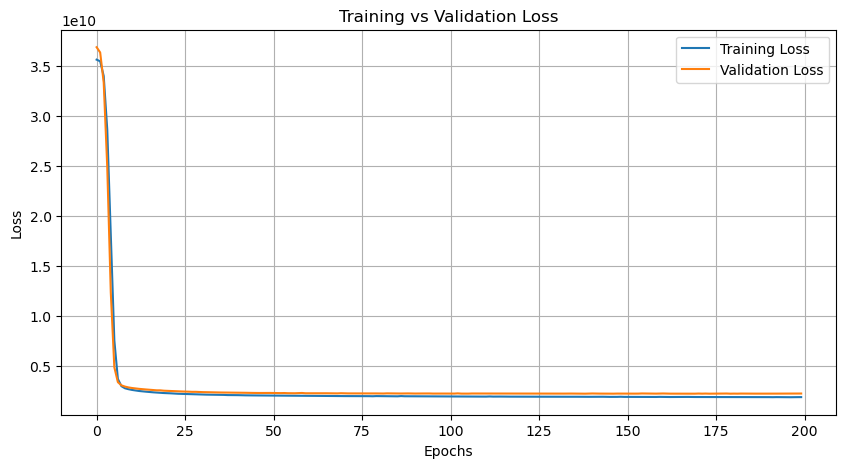

In [32]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(10, 5))

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Saving and Loading Best Model
model.load_state_dict(torch.load("best_model.pt"))

In [33]:
#Evaluate the Model
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 1835937152.0
Testing MSE: 2272167168.0


In [34]:
print("r2_score  value: ",r2_score(y_test,test_pred))

r2_score  value:  0.37681736987196157


In [35]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=["predicted_values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual_values"])

pd.concat([predicted_df,actual_df],axis = 1)

,predicted_values,Actual_values
0,272790.625000,501837.00000
1,254545.296875,372500.00000
2,145940.812500,180921.19589
3,183103.875000,180921.19589
4,203364.890625,180921.19589
...,...,...
578,156267.281250,134000.00000
579,208138.375000,213250.00000
580,190713.640625,180921.19589
581,179294.921875,180921.19589
